### **Report Details**

* **Student:** Ahmed Al-Muharaq
* **Professor:** Salomon Michel
* **Course:** Machine Learning
* **Program:** Master 1 - Embedded Computing Systems (IoT)
* **Institution:** Université Marie & Louis Pasteur (UMLP), EIPHI Graduate School
* **Module/Topic:** Lab 1 Review

# The basics of Machine Learning

## 1 - Classification versus regression

In supervised learning, two classes of problems can be distinguished according to the kind of an output target data $y^t$ :

*   When $y^t$ is continuous ($y^t \in \mathbb{R}$) it is a regression problem;
*   When $y^t$ is discrete or category (like $y^t \in \{0,1\}$) it is a classification problem.

## 2 - Training a ML model

The data set, which is composed of data samples $(X_j,Y^t_j)_{j \in \{1,\dots,n\}}$, where $X_j=\left(x_{1j},\dots,x_{Ij}\right)$ and $Y^t_j=\left(y^t_{1j},\dots,y^t_{Oj}\right)$ with $I$ and $O$ being the number of input and output variables respectively,, is usually divided into three sets (examples possible splitting ratio are given between brackets; their sum must be always equal to 100%):
1.   training / learning set $(X_{train},Y^t_{train})$ (60%; 70%; 70%)
2.   validation set $(X_{validation},Y^t_{validation})$ (20%; 15%; 0%)
3.   test set $(X_{test},Y^t_{test})$ (20%; 15%; 30%)

The training set contains the data used to find the model's optimal parameters, while the validation set is used to check whether the training is still relevant or whether an overfit appears, meaning that the model is no longer able to generalize and therefore give good predictions for the new data encountered. The test set is used to evaluate the model's performance once training is complete.

Finding a model's optimal parameters means to find a set of parameters $\Theta$ (the set of synaptic weights $W$ in the context of a neural network) such that the model gives good predictions $Y$ for inputs $X$ considering a giving configuration of model's hyperparameters (learning rate, tree depth, and so on). This is done by finding a set $\hat{\Theta}$ that minimizes an Error / Loss function $L$ that drives the training
$$ \min_{\Theta} \left[ \frac{1}{n} \sum_{j=1}^{n} L\left(P_\Theta(X_j),Y^t_j\right) \right]$$
where $P_\Theta(X_j)$ is the model's prediction for a data sample $(X_j,Y^t_j)$ belonging to $(X_{train},Y^t_{train})$.

A common choice for the loss function is the Mean Squared Error $\rightarrow L\left(y,y^t\right) = \frac{1}{2} \left(y - y^t\right)^2$, where $\frac{1}{2}$ can be dropped.

## 3 - Evaluating the performance of a Machine Learning model

Once $\hat{\Theta}$ found, the model is evaluated on the test set $(X_{test},Y^t_{test})$ using a metric $d(P_{\hat{\Theta}}(X_{test}),Y^t_{test}) \in \mathbb{R}$, which can the loss function $L$ or another one not used for training.

## 4 - Optimization of hyperparameters

Once the model trained and evaluated, a further step is to optimize the hyperparameters of the model. This is one of the work a data scientist needs to complete. Indeed, for a given problem he must not only find the most suited machine learning model, but also find the best hyperparameters.

## 1 - Mount the Google drive and load the data set

# What are you going to do?

In this lab you'll first train and evaluate the logistic regression model. Then in Lab2 another regression problem will be faced using decision trees and random forests.

In this Colab notebook you have to complete following steps:
1.   Download and open the following [data set](https://filesender.renater.fr/?s=download&token=ffd51567-b6a4-4eb8-bced-01e8546afde0) using pandas
2.   Visualize the data and show the histogram of wines ratings
3.   Split the data set in train and test sets. Does the distribution of scores vary between the train and the test? Compared to the original dataset? How can a balanced separation be achieved?
4.   What is the nature of each feature? What do you notice? Adapt the dataset accordingly.
5.   Train a classifier with scikit-learn: logistic regression and evaluate its performance using scikit-learn and metrics adapted to classification.



In [2]:

# 1 - Mount the Google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [13]:
# Download the actual wine quality dataset directly from a public source
!wget -O winequality.csv "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

# Quick check to verify it is CSV data
with open('winequality.csv', 'r') as f:
    print("First line of file:", f.readline())

--2026-05-28 12:09:09--  https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘winequality.csv’

winequality.csv         [ <=>                ] 258.23K  --.-KB/s    in 0.04s   

2026-05-28 12:09:09 (6.60 MB/s) - ‘winequality.csv’ saved [264426]

First line of file: "fixed acidity";"volatile acidity";"citric acid";"residual sugar";"chlorides";"free sulfur dioxide";"total sulfur dioxide";"density";"pH";"sulphates";"alcohol";"quality"



In [3]:
!ls -l gdrive/'My Drive'/'Colab Notebooks'

total 8762
-rw------- 1 root root  319862 May 12 12:23 'CIFAR-100 CNN project.ipynb'
-rw------- 1 root root  176313 May 12 13:59 'CIFAR-100 Image Classification with a Convolutional Neural Network (CNN).ipynb'
-rw------- 1 root root  487671 May  7 17:51  CIFAR100_NEW.ipynb
-rw------- 1 root root  489361 May 19 12:12 'Classifying Tiny ImageNet with CNNs.ipynb'
-rw------- 1 root root  237884 May 27 12:25  dropout_cifar10_cifar100.ipynb
-rw------- 1 root root   33999 Dec  8 19:43 ' Ihear_scramb.mp4.ipynb'
-rw------- 1 root root   10887 May 28 12:06  Lab1_LogisticRegression_Metrics_to_complete.ipynb
-rw------- 1 root root  113496 May 12 12:20 'MNIST CNN.ipynb'
-rw------- 1 root root    4527 Apr  2 09:29  TP1.ipynb
-rw------- 1 root root     306 May 28 12:05  Untitled
-rw------- 1 root root   11941 Dec  8 15:47  Untitled0.ipynb
-rw------- 1 root root     306 May 27 08:23 'Untitled (1)'
-rw------- 1 root root 7071284 Dec  8 18:45  Untitled1.ipynb
-rw------- 1 root root     324 May 12 14:00  

In [12]:
# 2 - Load raw data
import pandas as pd

# The UCI dataset uses semicolons as separators
df = pd.read_csv('winequality.csv', sep=';')

# Adding a 'color' column since later cells expect it (assuming white wine based on the URL used above)
df['color'] = 'white'

print("Data loaded successfully!")
display(df.head())

Data loaded successfully!


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,white
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,white
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,white
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white


## 2 - Visualize data, display an histogram showing the wine ratings (*quality values*) distribution

In [14]:
# 1 - Display columns names
print(df.columns.tolist())

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'color']


In [17]:
# 2 - Show the top rows of the data
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,white
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,white
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,white
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white


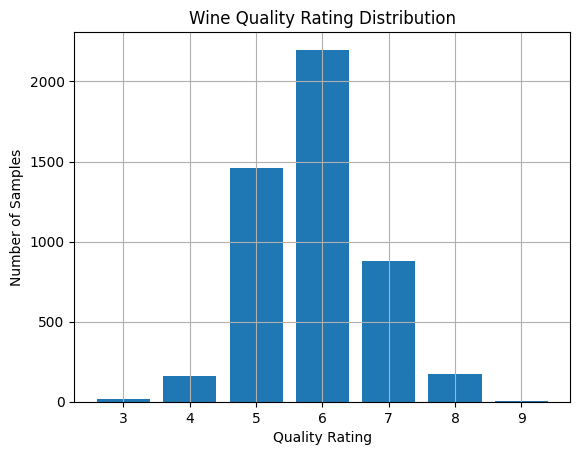

In [15]:
# 3 - Plot the wine ratings
import matplotlib.pyplot as plt
df['quality'].hist(bins=range(3, 11), align='left', rwidth=0.8)
plt.xlabel('Quality Rating')
plt.ylabel('Number of Samples')
plt.title('Wine Quality Rating Distribution')
plt.show()

## 3 - First, define $Y$ (output) as the *quality* values and $X$ as the remaining columns. Second, split the data set into train and test sets (split ratio of 50%) using a function from [scikit-learn](https://scikit-learn.org/stable/)'s *Model selection*. What can you say about the data distribution of both sets (*display them in an histogram*). Third, use parameter *stratify* to obtain the same distribution of the ratings, especially for the one with the fewest occurrences (extreme values). Once done display the new histogram to show the result.

In [18]:
from sklearn.model_selection import train_test_split
# 1 - Define X and Y
X = df.drop(columns=['quality'])
y = df['quality']
# 2 - Split data set into training and test sets using a ratio of 50%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)
X_train.shape, X_test.shape

((2449, 12), (2449, 12))

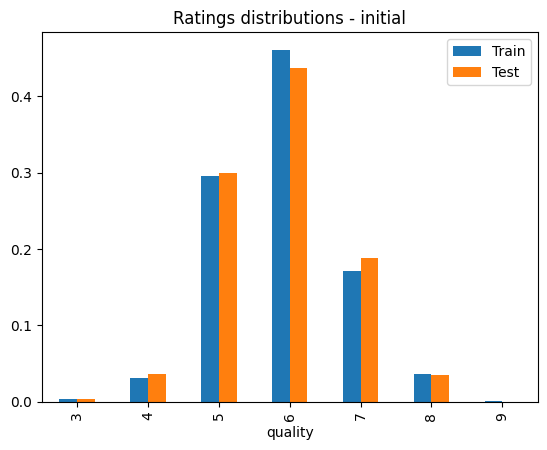

In [19]:
# 3 - Display the both data samples distributions (train and test)
import pandas as pd
ax = pd.DataFrame({
    'Train': y_train.value_counts(normalize=True),
    'Test': y_test.value_counts(normalize=True)
}).sort_index().plot(kind='bar')
ax.set_title("Ratings distributions - initial")
ax.legend();

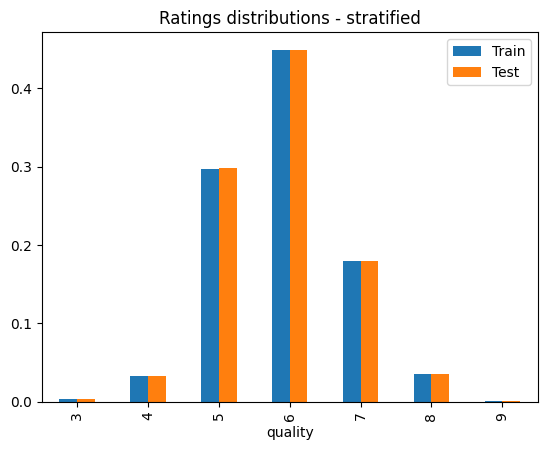

In [20]:
# 4 - Stratify the way the samples are distributed into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y, random_state=0)
X_train.shape, X_test.shape
ax = pd.DataFrame({
    'Train': y_train.value_counts(normalize=True),
    'Test': y_test.value_counts(normalize=True)
}).sort_index().plot(kind='bar')
ax.set_title("Ratings distributions - stratified")
ax.legend();

## 4 - First, what are the types (integer, float, and so on) of values of the different variables / features of an input sample X? Second, what can you notice? Third, update the problematic variable / feature such that it becomes numeric and then split again the data set into train and test sets, but such that their respective ratio is 70% and 30%.

In [21]:
# 1 - Show the types
df.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [22]:
# 2 - Show the possible values of the problematic variable / feature
df['color'].unique()

array(['white'], dtype=object)

In [23]:
# 3 - Update variable to become a numerical value
df['color'] = df['color'].map({'red': 1, 'white': 0})

# 4 - Split again data set into train and test sets
X = df.drop(columns=['quality'])
y = df['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
df.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


## 5 - First, train a classifier using logistic regression from *Linear model* in scikit-learn. Second, display the prediction obtained for each of the five first samples of the test set. Third, use the function classification_report of scikit-learn to evaluate the classifier's performance. What is support value? How are computed precision, recall and f1-score? What are macro and weighted averaging? What can you conclude from the values?

In [24]:
# 1a - Try to train logistic regression
from sklearn.linear_model import LogisticRegression

try:
    # Increasing max_iter to help convergence on unscaled data
    lr_unscaled = LogisticRegression(max_iter=10000, random_state=0)
    lr_unscaled.fit(X_train, y_train)
    print("Unscaled model training complete.")
except NameError:
    print("Error: X_train or y_train not found. Please ensure you have run the data splitting cells above (Section 3 and 4) before running this cell.")

Unscaled model training complete.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [25]:
# 1b - Train logistic regression again using StandardScaler as preprocessing
from sklearn import preprocessing
scaler = preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

lr = LogisticRegression(max_iter=1000, random_state=0)
lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=0)

In [26]:
# 2 - Predict value for the five first test samples
X_test_scaled = scaler.transform(X_test)

Y_pred = lr.predict(X_test_scaled[:5])
print(Y_pred)

[6 6 6 6 5]


In [27]:
# 3 - Show classification performance using function classification_report of metrics
from sklearn.metrics import classification_report

y_pred = lr.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           3       1.00      0.17      0.29         6
           4       0.70      0.14      0.24        49
           5       0.61      0.55      0.58       437
           6       0.53      0.76      0.62       660
           7       0.51      0.21      0.30       264
           8       0.00      0.00      0.00        53
           9       0.00      0.00      0.00         1

    accuracy                           0.55      1470
   macro avg       0.48      0.26      0.29      1470
weighted avg       0.54      0.55      0.51      1470



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Conclusions

### 1. Model Performance Analysis
The Logistic Regression model achieved an overall **accuracy of approximately 55%**. While this is better than random guessing (given there are 7 quality classes), the model struggles with extreme values:
* **Majority Classes (5, 6):** These have the highest F1-scores because they dominate the dataset.
* **Minority Classes (3, 4, 8, 9):** The model performs poorly or fails entirely (e.g., quality 8 and 9) due to insufficient samples, even with stratification.

### 2. Understanding the Metrics
* **Support:** The actual number of occurrences of the class in the specified dataset. For example, there was only 1 sample for quality '9'.
* **Precision:** Accuracy of positive predictions ($TP / (TP + FP)$). High precision means the model didn't label a 'bad' wine as 'good'.
* **Recall:** Ability of the model to find all positive samples ($TP / (TP + FN)$).
* **F1-Score:** The harmonic mean of precision and recall.
* **Macro Avg:** The average of the metric calculated for each class independently (treats all classes equally, regardless of size).
* **Weighted Avg:** The average of the metric where each class's score is weighted by its support (better for imbalanced datasets).

### 3. Key Takeaways
- **Feature Scaling matters:** Without `StandardScaler`, the model failed to converge due to the different scales of features like 'total sulfur dioxide' vs 'chlorides'.
- **Data Imbalance:** Even with stratification, the extreme rarity of certain quality scores makes them nearly impossible to predict with a simple linear model.
- **Linearity:** Logistic Regression assumes a linear relationship between features and the log-odds of the classes. Wine quality might be better captured by non-linear models like Random Forests (as suggested for Lab 2).

###  Lab 1 Conclusion: Logistic Regression and Metrics

#### 1. Definition of Metric Terms

* **Support:** The number of actual occurrences of each class in the test set. It indicates whether the dataset is balanced or imbalanced.
* **Precision:** The ratio of true positives to total predicted positives ($\frac{TP}{TP + FP}$). It measures the accuracy of positive predictions.
* **Recall:** The ratio of true positives to total actual positives ($\frac{TP}{TP + FN}$). It measures how well the model finds all positive instances.
* **F1-Score:** The harmonic mean of precision and recall ($2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$). It provides a single balanced metric.
* **Macro Averaging:** Computes metrics for each class independently, then takes the unweighted average. It treats all classes equally.
* **Weighted Averaging:** Computes metrics for each class, then takes the average weighted by the support (frequency) of each class.

#### 2. Analysis of the Results

* **Class Imbalance:** The dataset is extremely imbalanced. Ratings 5 and 6 make up the vast majority of samples, while extreme ratings (3 and 9) are very rare.
* **Model Bias:** Due to this imbalance, the model is biased. It achieves decent F1-scores on common classes but fails on class 8 and 9 because it doesn't have enough rare data to learn from.
* **Importance of Feature Scaling:** Without `StandardScaler`, the Logistic Regression solver fails to converge because features are on vastly different scales.

#### 3. General Conclusion

Standard Logistic Regression is highly sensitive to feature scales and class imbalances. While feature scaling stabilizes the model, handling class imbalance (e.g., using `class_weight='balanced'`, oversampling rare classes, or grouping ratings into binary classes) is necessary to correctly classify extreme quality categories.